In [10]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



import kagglehub


/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/custom.css
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/models/label_encoder.pkl
/kaggle/input/notebooks/hafsaferdousi5/2-2xgboost/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/2-2xgboost/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/2-2xgboost/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/2-2xgboost/custom.css
/kaggle/input/notebooks/hafsaferdousi5/2-2xgboost/outputs/results/Xgboost_metrics.csv
/kaggle/input/notebooks/hafsaferdousi5/2-2xgboost/outputs/results/xgb_confusion_matrix.png
/kaggle/input/notebooks/hafsaferdousi5/2-2xgboost/outputs/results/xg

In [14]:
import joblib

X_train, X_test, y_train, y_test = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl"
)



print(X_train.shape)
print(X_test.shape)

(5055991, 77)
(1263998, 77)


In [2]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import joblib
import os


In [4]:
rf = joblib.load("/kaggle/input/notebooks/hafsaferdousi5/2-model-rf/outputs/models/random_forest.pkl")

xgb = joblib.load("/kaggle/input/notebooks/hafsaferdousi5/2-2xgboost/outputs/models/XGboost.pkl")

lgb = joblib.load("/kaggle/input/notebooks/hafsaferdousi5/2-2model-lightgbm/outputs/models/lightgbm_leaves31.pkl")

cat = joblib.load("/kaggle/input/notebooks/hafsaferdousi5/02-2model-catboost/outputs/models/catboost.pkl")

In [15]:
import numpy as np

rf_pred  = rf.predict_proba(X_train)
xgb_pred = xgb.predict_proba(X_train)
lgb_pred = lgb.predict_proba(X_train)
cat_pred = cat.predict_proba(X_train)

meta_X_train = np.hstack([
    rf_pred,
    xgb_pred,
    lgb_pred,
    cat_pred
])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

meta_model.fit(meta_X_train, y_train)

LogisticRegression(max_iter=2000, random_state=42)

In [17]:
meta_X_test = np.hstack([
    rf.predict_proba(X_test),
    xgb.predict_proba(X_test),
    lgb.predict_proba(X_test),
    cat.predict_proba(X_test)
])

y_pred = meta_model.predict(meta_X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [20]:
print(meta_X_train.shape)

(5055991, 60)


In [21]:
y_pred = meta_model.predict(meta_X_test)

y_prob = meta_model.predict_proba(meta_X_test)

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import numpy as np

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
mcc = matthews_corrcoef(y_test, y_pred)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
auc = roc_auc_score(
    y_test_bin,
    y_prob,
    average="weighted",
    multi_class="ovr"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"MCC      : {mcc:.4f}")
print(f"AUC      : {auc:.4f}")

Accuracy : 0.9717
Precision: 0.9674
Recall   : 0.9717
F1-score : 0.9695
MCC      : 0.9217
AUC      : 0.9878


In [24]:
attack_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]

from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    y_pred,
    labels=range(15),
    target_names=attack_names,
    zero_division=0
))

                          precision    recall  f1-score   support

                  Benign       0.98      0.99      0.98    998829
                     Bot       1.00      1.00      1.00     28907
        Brute Force -Web       0.69      0.59      0.63       111
        Brute Force -XSS       1.00      0.58      0.73        45
        DDOS attack-HOIC       1.00      1.00      1.00     39772
    DDoS attack-LOIC-UDP       0.90      0.95      0.92       346
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    115073
   DoS attacks-GoldenEye       1.00      1.00      1.00      8281
        DoS attacks-Hulk       1.00      1.00      1.00     29040
DoS attacks-SlowHTTPTest       0.00      0.00      0.00        11
   DoS attacks-Slowloris       0.99      0.99      0.99      1982
          FTP-BruteForce       0.00      0.00      0.00        10
            Infiltration       0.12      0.08      0.10     22764
           SQL Injection       0.00      0.00      0.00        17
         

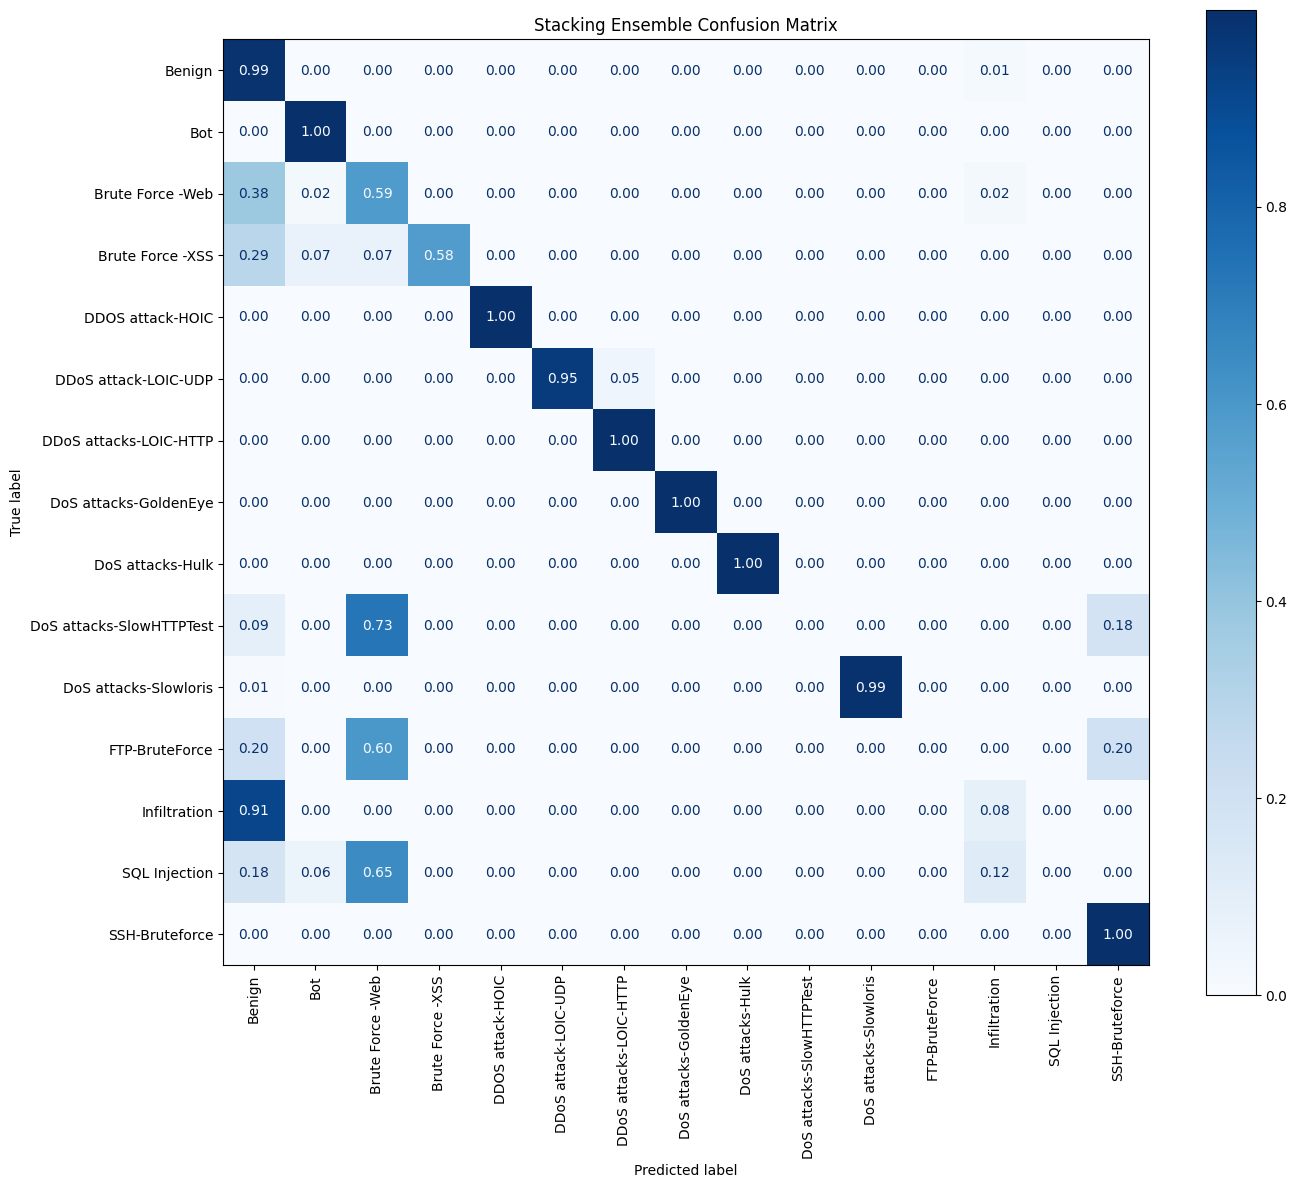

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title("Stacking Ensemble Confusion Matrix")
plt.tight_layout()
plt.show()

In [5]:
estimators = [
    ("rf", rf),
    ("xgb", xgb),
    ("lgb", lgb),
    ("cat", cat)
]

In [6]:
meta_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

In [7]:
stack_model = StackingClassifier(

    estimators=estimators,

    final_estimator=meta_model,

    stack_method="predict_proba",

    cv=5,

    n_jobs=-1,

    passthrough=False
)

In [3]:

os.makedirs("outputs/models", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)

In [26]:
import joblib
import os

os.makedirs("outputs/models", exist_ok=True)

joblib.dump(
    meta_model,
    "outputs/models/stacking_meta_lr.pkl"
)

['outputs/models/stacking_meta_lr.pkl']

In [27]:
stacking_model = {
    "rf": rf,
    "xgb": xgb,
    "lgb": lgb,
    "cat": cat,
    "meta": meta_model
}

joblib.dump(
    stacking_model,
    "outputs/models/stacking_ensemble.pkl"
)

['outputs/models/stacking_ensemble.pkl']

In [30]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Model": ["stacking"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1],
    "MCC": [mcc],
    "AUC": [auc]
})

metrics_df.to_csv(
    "outputs/results/stacking_ensemble.csv",
    index=False
)

print(metrics_df)

      Model  Accuracy  Precision    Recall        F1       MCC      AUC
0  stacking  0.971724    0.96738  0.971724  0.969494  0.921724  0.98781


In [31]:
from sklearn.metrics import classification_report

attack_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]
report = classification_report(
    y_test,
    y_pred,
    labels=range(15),
    target_names=attack_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "outputs/results/stacking_ensemble_classification_report.csv"
)

print("Classification Report Saved!")

Classification Report Saved!


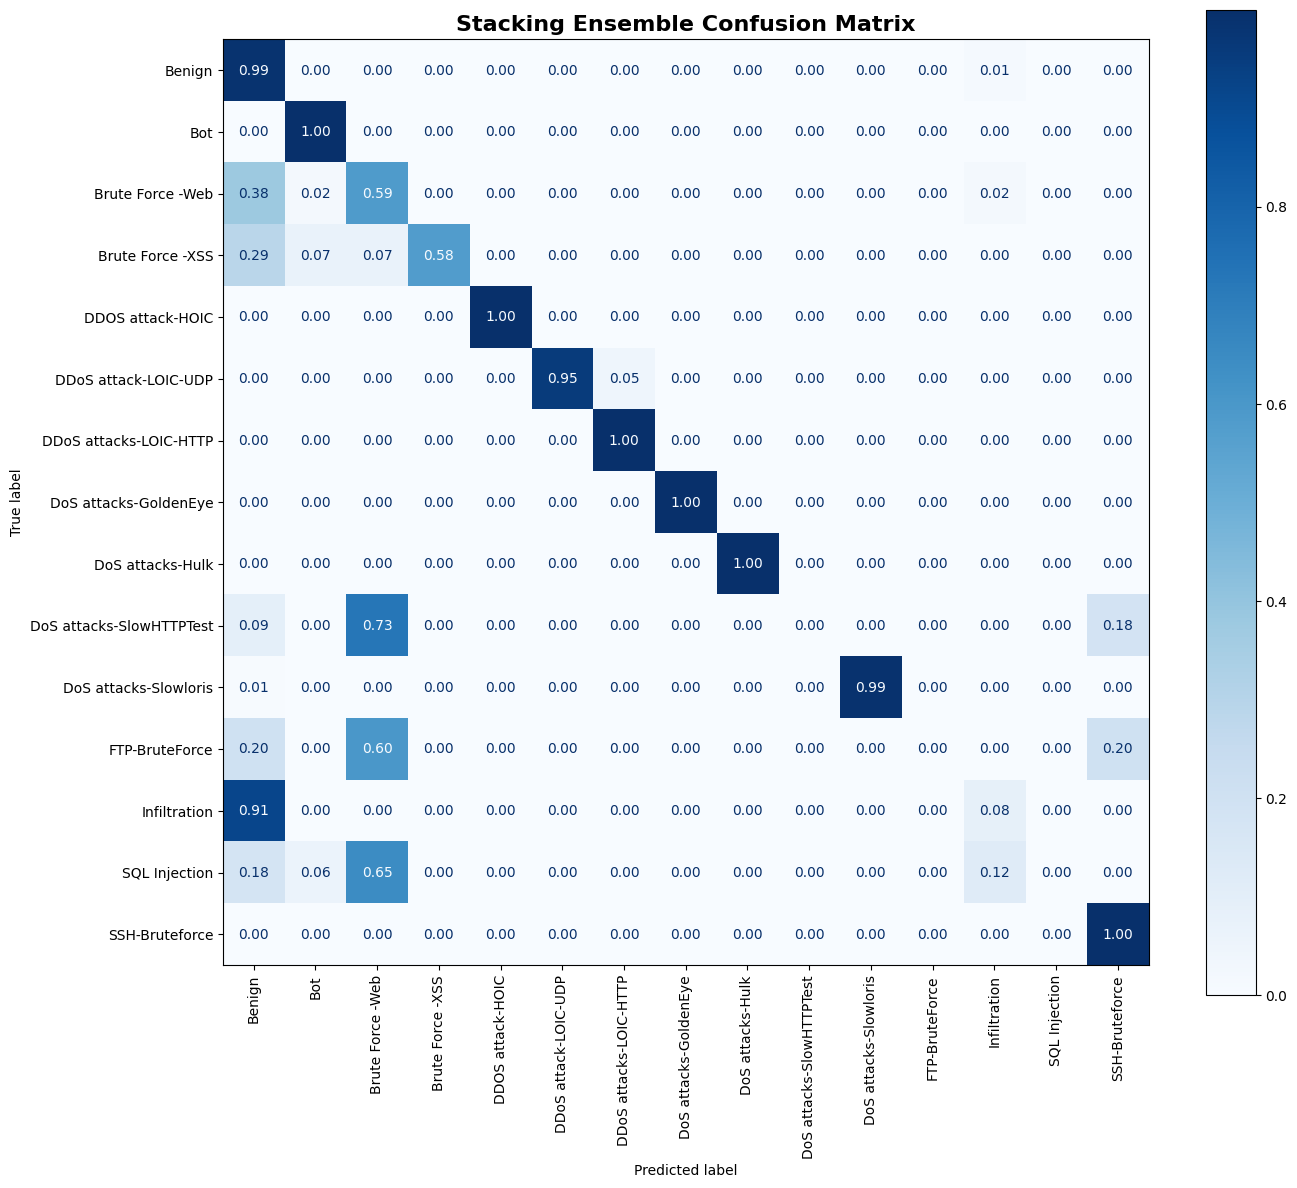

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Stacking Ensemble Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "outputs/results/stacking_ensemble_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()